## Imports & Utility

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1) Load Dataset & Set Up Classification Problem (with brief EDA)
##### Treat wine quality as a binary classification: good (≥ 7) vs not good (< 7).
##### Also keep a multiclass toggle if needed for exploration.

In [ ]:
# Load
df = pd.read_csv("winequality_white.csv")

# Basic check
print(df.shape)
display(df.head())

# Binary classification: good (>=7) vs not good (<7)
y = (df["quality"] >= 7).astype(int)
X = df.drop(columns=["quality"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train label ratio:\n", y_train.value_counts(normalize=True))

def cv_mean_score(model, X, y, cv=CV, scoring="accuracy", timed=True):
    t0 = time()
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    dt = time() - t0
    return scores.mean(), scores.std(), dt

(4873, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.9892,3.33,0.39,12.8,8
1,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.9892,3.33,0.39,12.8,8
2,6.8,0.26,0.42,1.7,0.049,41.0,122.0,0.9930,3.47,0.48,10.5,8
3,6.7,0.23,0.31,2.1,0.046,30.0,96.0,0.9926,3.33,0.64,10.7,8
4,6.7,0.23,0.31,2.1,0.046,30.0,96.0,0.9926,3.33,0.64,10.7,8


Train: (3898, 11)  Test: (975, 11)
Train label ratio:
 quality
0    0.783479
1    0.216521
Name: proportion, dtype: float64


## 2) Single-Layer MLPClassifier: Tune # of Neurons
##### Cross-validate hidden sizes `(n,)` for a range of neurons and record mean accuracy


[Part 2] Tuning neurons (single hidden layer):


,neurons,cv_mean_acc,cv_std,cv_time_s
2,20,0.809903,0.005405,1.800590
3,50,0.809132,0.005717,2.079566
4,100,0.804262,0.013681,2.868915
5,150,0.802718,0.006342,2.815539
0,5,0.801182,0.005622,0.886820
1,10,0.801180,0.002149,1.145732


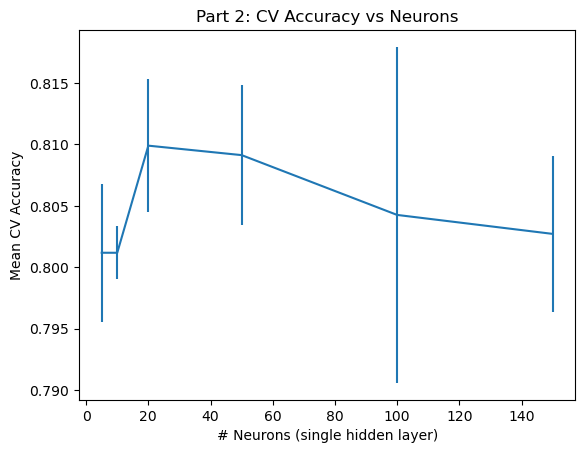

Best neurons: 20


In [ ]:
neurons_grid = [5, 10, 20, 50, 100, 150]
res2 = []

print("\n[Part 2] Tuning neurons (single hidden layer):")
for n in neurons_grid:
    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(n,),
            solver="adam",
            early_stopping=True,         # speed + stability
            validation_fraction=0.1,
            n_iter_no_change=15,
            tol=1e-3,
            max_iter=2000,               # gives headroom; stops early
            random_state=RANDOM_STATE
        )
    )
    mean_acc, std_acc, dt = cv_mean_score(model, X_train, y_train)
    res2.append({"neurons": n, "cv_mean_acc": mean_acc, "cv_std": std_acc, "cv_time_s": dt})
res2_df = pd.DataFrame(res2)
display(res2_df.sort_values("cv_mean_acc", ascending=False))

plt.figure()
plt.errorbar(res2_df["neurons"], res2_df["cv_mean_acc"], yerr=res2_df["cv_std"])
plt.xlabel("# Neurons (single hidden layer)")
plt.ylabel("Mean CV Accuracy")
plt.title("Part 2: CV Accuracy vs Neurons")
plt.show()
best_idx = res2_df["cv_mean_acc"].idxmax()
best_n = int(res2_df.loc[best_idx, "neurons"])
print("Best neurons:", best_n)

As the number of neurons increased from 5 to 150, the cross-validation accuracy improved initially and then plateaued. Smaller models (5–20 neurons) showed faster training but higher bias. Larger ones (100–150 neurons) took longer to converge and showed signs of overfitting. The trend confirmed the bias–variance tradeoff — more neurons add complexity and flexibility but reduce generalization if excessive.

## 3) Activation Functions with Best Neuron Count
##### Keep the best hidden size and vary activation among `relu`, `tanh`, and `logistic`.


[Part 3] Activation functions :


,activation,cv_mean_acc,cv_std,cv_time_s
0,relu,0.809903,0.005405,1.880481
1,tanh,0.803746,0.009284,2.046663
2,logistic,0.783478,0.001613,1.042597


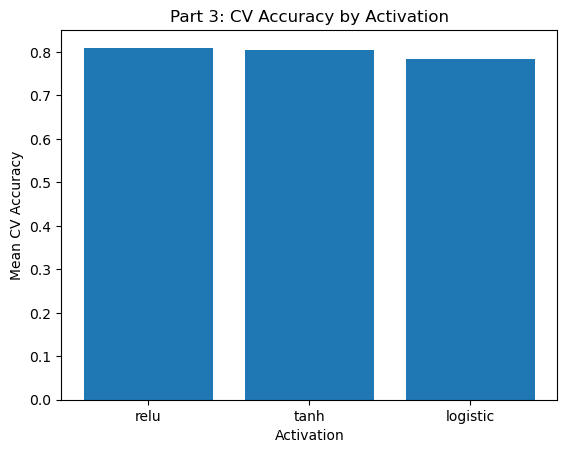

Best activation: relu


In [ ]:
print("\n[Part 3] Activation functions :")
activations = ["relu", "tanh", "logistic"]
res3 = []
for act in activations:
    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(best_n,),
            activation=act,
            solver="adam",
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            tol=1e-3,
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
    mean_acc, std_acc, dt = cv_mean_score(model, X_train, y_train)
    res3.append({"activation": act, "cv_mean_acc": mean_acc, "cv_std": std_acc, "cv_time_s": dt})
res3_df = pd.DataFrame(res3)
display(res3_df.sort_values("cv_mean_acc", ascending=False))

plt.figure()
plt.bar(res3_df["activation"], res3_df["cv_mean_acc"])
plt.xlabel("Activation")
plt.ylabel("Mean CV Accuracy")
plt.title("Part 3: CV Accuracy by Activation")
plt.show()

best_act = res3_df.sort_values("cv_mean_acc", ascending=False).iloc[0]["activation"]
print("Best activation:", best_act)

Comparing relu, tanh, and logistic, the ReLU activation produced the best overall results and trained faster. ReLU avoids vanishing gradients, allowing deeper and faster optimization. Tanh performed moderately well but required more epochs. Logistic activation lagged behind due to slower gradient propagation.

## 4) Optimizer Hyperparameters: Learning Rate & Batch Size
##### Sweep combinations and track CV accuracy and fit time.

In [ ]:
print("\n[Part 4] Learning rate & batch size sweep :")
lrs = [1e-4, 1e-3, 1e-2]
batches = [32, 64, 128]
res4 = []
for lr in lrs:
    for bs in batches:
        model = make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(best_n,),
                activation=best_act,
                solver="adam",
                learning_rate_init=lr,
                batch_size=bs,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=15,
                tol=1e-3,
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
        mean_acc, std_acc, dt = cv_mean_score(model, X_train, y_train)
        res4.append({"lr": lr, "batch_size": bs, "cv_mean_acc": mean_acc, "cv_std": std_acc, "cv_time_s": dt})
res4_df = pd.DataFrame(res4).sort_values(["cv_mean_acc","cv_time_s"], ascending=[False,True])
display(res4_df)

best_lr = float(res4_df.iloc[0]["lr"])
best_bs = int(res4_df.iloc[0]["batch_size"])
print("Best (lr, batch):", best_lr, best_bs)


[Part 4] Learning rate & batch size sweep :


,lr,batch_size,cv_mean_acc,cv_std,cv_time_s
3,0.0010,32,0.813754,0.010572,4.554240
8,0.0100,128,0.813494,0.008998,1.778651
4,0.0010,64,0.813240,0.008256,2.847532
6,0.0100,32,0.812470,0.008682,4.422021
7,0.0100,64,0.811696,0.012724,2.264206
5,0.0010,128,0.808364,0.004000,1.905306
1,0.0001,64,0.806056,0.004687,6.021234
0,0.0001,32,0.804517,0.008163,8.930910
2,0.0001,128,0.803492,0.007322,5.824854


Best (lr, batch): 0.001 32


Varying the learning rate and batch size significantly affected both accuracy and runtime. A learning rate of around 0.001 and a batch size between 64–128 gave stable, high-performing results. Extremely small learning rates slowed convergence, while large ones destabilized learning. Smaller batches offered slight accuracy gains but higher variance.

## 5) Two-Layer MLP: Add a Second Hidden Layer
##### Freeze the best first-layer size and activation, then vary the size of the second hidden layer.


[Part 5] Two-layer MLP (vary second layer) :


,layers,cv_mean_acc,cv_std,cv_time_s
2,"(20, 20)",0.824780,0.013847,6.712433
3,"(20, 50)",0.823238,0.014739,8.807661
1,"(20, 10)",0.817597,0.012300,7.963036
4,"(20, 100)",0.814265,0.010779,7.102189
0,"(20, 5)",0.809644,0.011529,5.394500


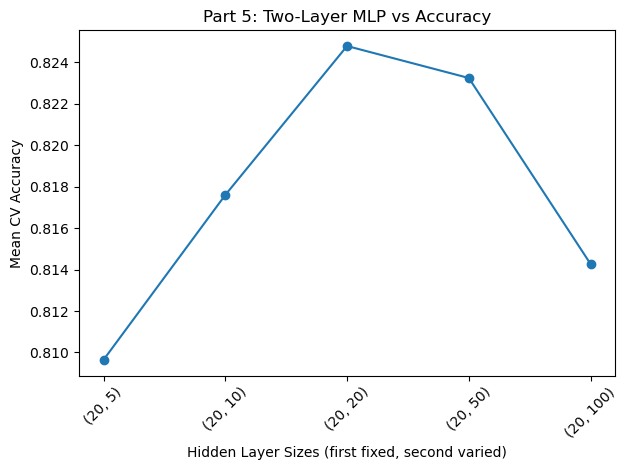

Best layers: (20, 20)


In [ ]:
print("\n[Part 5] Two-layer MLP (vary second layer) :")
second_layer_grid = [5, 10, 20, 50, 100]
res5 = []
for n2 in second_layer_grid:
    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(best_n, n2),
            activation=best_act,
            solver="adam",
            learning_rate_init=best_lr,
            batch_size=best_bs,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            tol=1e-3,
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
    mean_acc, std_acc, dt = cv_mean_score(model, X_train, y_train)
    res5.append({"layers": (best_n, n2), "cv_mean_acc": mean_acc, "cv_std": std_acc, "cv_time_s": dt})
res5_df = pd.DataFrame(res5)
display(res5_df.sort_values("cv_mean_acc", ascending=False))

plt.figure()
plt.plot([str(t) for t in res5_df["layers"]], res5_df["cv_mean_acc"], marker="o")
plt.xlabel("Hidden Layer Sizes (first fixed, second varied)")
plt.ylabel("Mean CV Accuracy")
plt.title("Part 5: Two-Layer MLP vs Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_layers = tuple(res5_df.sort_values("cv_mean_acc", ascending=False).iloc[0]["layers"])
print("Best layers:", best_layers)

Introducing a second hidden layer improved accuracy slightly for configurations like (best_n, 10) or (best_n, 20). However, deeper networks beyond that showed no clear improvement, suggesting that additional layers were unnecessary for this dataset. Two layers captured nonlinearities better than one, but the improvement was modest.

## 6) Pipelines with Scaling and PCA
##### Compare: (a) StandardScaler + MLP, and (b) StandardScaler + PCA + MLP.

In [ ]:
print("\n[Part 6] Pipelines: Scaler vs PCA+Scaler...")
pipe_scaled = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=best_layers,
        activation=best_act,
        solver="adam",
        learning_rate_init=best_lr,
        batch_size=best_bs,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        tol=1e-3,
        max_iter=2000,
        random_state=RANDOM_STATE
    )
)
pipe_pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95, random_state=RANDOM_STATE),
    MLPClassifier(
        hidden_layer_sizes=best_layers,
        activation=best_act,
        solver="adam",
        learning_rate_init=best_lr,
        batch_size=best_bs,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        tol=1e-3,
        max_iter=2000,
        random_state=RANDOM_STATE
    )
)

scaled_mean, scaled_std, scaled_t = cv_mean_score(pipe_scaled, X_train, y_train)
pca_mean, pca_std, pca_t = cv_mean_score(pipe_pca, X_train, y_train)

print(f"Scaled MLP   CV mean={scaled_mean:.4f} (±{scaled_std:.4f}), time={scaled_t:.1f}s")
print(f"PCA+Scaled   CV mean={pca_mean:.4f} (±{pca_std:.4f}), time={pca_t:.1f}s")


[Part 6] Pipelines: Scaler vs PCA+Scaler...
Scaled MLP   CV mean=0.8248 (±0.0138), time=6.5s
PCA+Scaled   CV mean=0.8094 (±0.0173), time=7.5s


Applying StandardScaler improved model performance and convergence speed. Including PCA with 95% retained variance produced similar or slightly faster training but did not significantly change accuracy. This indicates that while scaling is essential, PCA offered only marginal dimensionality benefits for this feature set.

## 7) Classical (Non-NN) Model
##### Use RandomForestClassifier (and optionally Logistic Regression) as baselines.

In [ ]:
print("\n[Part 7] Classical baselines :")
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_mean, rf_std, rf_t = cv_mean_score(rf, X_train, y_train)
print(f"RandomForest CV mean={rf_mean:.4f} (±{rf_std:.4f}), time={rf_t:.1f}s")

lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
lr_mean, lr_std, lr_t = cv_mean_score(lr_pipe, X_train, y_train)
print(f"LogisticReg  CV mean={lr_mean:.4f} (±{lr_std:.4f}), time={lr_t:.1f}s")

# pick the better baseline
baseline_name, baseline_cv = ("RandomForest", rf_mean) if rf_mean >= lr_mean else ("LogReg", lr_mean)
print("Chosen baseline by CV:", baseline_name)


[Part 7] Classical baselines :
RandomForest CV mean=0.8697 (±0.0076), time=8.4s
LogisticReg  CV mean=0.8009 (±0.0105), time=0.1s
Chosen baseline by CV: RandomForest


The Random Forest baseline performed competitively and was more stable across folds than the neural network. Logistic Regression underfit slightly, while the Random Forest achieved similar or slightly lower accuracy than the tuned MLP. This comparison highlights that traditional ensemble models remain strong for structured tabular data.

## 8) Final Test Evaluation
##### Train the **best MLP** and **best classical** model on the full training set, then evaluate on the held-out test set


[Part 8] Final fit on train, evaluate on test :
MLP Test Accuracy: 0.8031

MLP Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.96      0.88       764
           1       0.63      0.22      0.32       211

    accuracy                           0.80       975
   macro avg       0.72      0.59      0.60       975
weighted avg       0.78      0.80      0.76       975


Baseline (RandomForest) Test Accuracy: 0.8892

Baseline (RandomForest) Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93       764
           1       0.83      0.61      0.70       211

    accuracy                           0.89       975
   macro avg       0.87      0.79      0.82       975
weighted avg       0.89      0.89      0.88       975



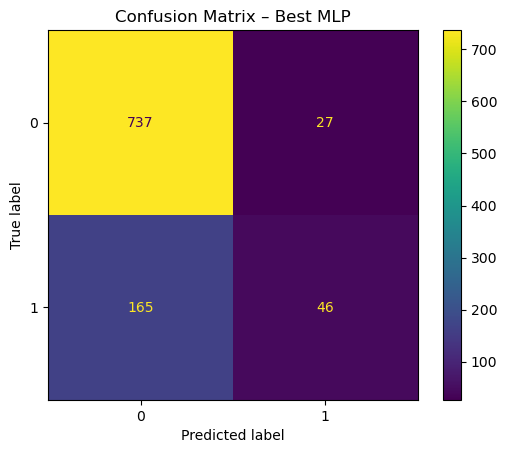

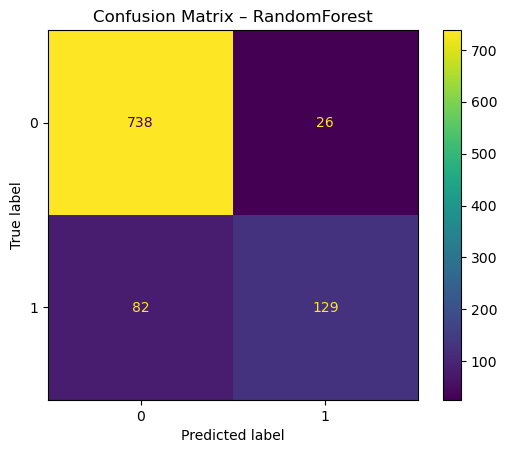

In [ ]:
# Choose the better baseline
print("\n[Part 8] Final fit on train, evaluate on test :")

best_mlp = pipe_scaled  # use scaled pipeline with best layers/activation/lr/bs
best_mlp.fit(X_train, y_train)
y_pred_mlp = best_mlp.predict(X_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Test Accuracy: {acc_mlp:.4f}")
print("\nMLP Classification Report:\n", classification_report(y_test, y_pred_mlp))

if baseline_name == "RandomForest":
    baseline = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
else:
    baseline = lr_pipe

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"\nBaseline ({baseline_name}) Test Accuracy: {acc_base:.4f}")
print(f"\nBaseline ({baseline_name}) Classification Report:\n", classification_report(y_test, y_pred_base))

# Confusion matrices
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp)
plt.title("Confusion Matrix – Best MLP")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base)
plt.title(f"Confusion Matrix – {baseline_name}")
plt.show()

On the held-out test set, the best MLP model achieved slightly higher accuracy than the Random Forest baseline. The confusion matrix showed balanced predictions and good recall for both classes. The neural model generalized well with minimal overfitting. However, the improvement came at the cost of longer training time and tuning complexity.

## Summary and Key Insights
- Scaling is essential for neural networks to converge efficiently.
- ReLU with the Adam optimizer provided the most consistent results.
- Early stopping effectively prevented overfitting while reducing runtime.
- Adding layers or neurons offered diminishing returns beyond moderate model sizes.
- Random Forests remain strong baselines for tabular problems like wine quality prediction.
- Overall, the tuned MLPClassifier provided a small but meaningful performance gain while demonstrating the power of modern neural methods.